In [23]:
import os
import pandas as pd
from datetime import datetime
import importlib
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

In [24]:
# Relative imports
os.chdir("..")
import hidden_state_model.processor
importlib.reload(hidden_state_model.processor)
Processor = hidden_state_model.processor.Processor
os.chdir("hidden_state_model")

### Read (and compact) dataframes

In [25]:
compact = True

In [26]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
for file in os.listdir("data"):
    if file.endswith(".parquet"):
        read.append(file)
        print(f"Reading {file}")
        df = pd.read_parquet(f"data/{file}")
        dfs.append(df)
    if file.endswith(".csv"):
        read.append(file)
        df = pd.read_csv(f"data/{file}", index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs)

if compact and len(dfs) > 10:
    print("Compacintg dfs")

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(f"data/compacted_{timestamp}.parquet")
    
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    trash = "data/trash"
    for f in read:
        os.rename(f"data/{f}", f"{trash}/{f}")

dfs = []  # Clear memory
raw_df

Reading combined.parquet


,prev_entry,public_cards,player_piles,current_player_i,bet_in_stage,bet_in_game,player_has_played,player_is_folded,first_better_i,big_blind,player_name,player_type,action,amount,p,relative_ev,rank,tiebreakers,hand_index,state_id
state_id,,,,,,,,,,,,,,,,,,,,
32e30c0a-821c-4bcb-9986-2844eb402812,None,[],"[98, 96]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,Tord,HumanPlayer,call,2,0.3953,0.011859,0,"[2, 1, 0, 0, 0]",NaN,NaN
b7ec800e-1e76-4d7f-9221-9a9602769945,32e30c0a-821c-4bcb-9986-2844eb402812,"[31, 15, 11]","[96, 96]",0,"[0, 0]","[4, 4]","[False, False]","[False, False]",0,4,Tord,HumanPlayer,raise,4,0.5987,0.023948,1,"[2, 11, 5, 1, 0]",NaN,NaN
7fa95b11-9edb-4c33-810e-dafe3e297db9,b7ec800e-1e76-4d7f-9221-9a9602769945,"[31, 15, 11]","[92, 88]",0,"[4, 8]","[8, 12]","[True, True]","[False, False]",0,4,Tord,HumanPlayer,call,4,0.5987,0.059870,1,"[2, 11, 5, 1, 0]",NaN,NaN
e93561e9-938c-4140-a5d7-35eb2946f461,7fa95b11-9edb-4c33-810e-dafe3e297db9,"[31, 15, 11, 50]","[88, 88]",0,"[0, 0]","[12, 12]","[False, False]","[False, False]",0,4,Tord,HumanPlayer,check,0,0.5906,0.070872,2,"[11, 2, 5, 0, 0]",NaN,NaN
a2683c14-bd1c-431e-9cf1-5486dcc70d4b,e93561e9-938c-4140-a5d7-35eb2946f461,"[31, 15, 11, 50]","[88, 77]",0,"[0, 11]","[12, 23]","[True, True]","[False, False]",0,4,Tord,HumanPlayer,call,11,0.5906,0.103355,2,"[11, 2, 5, 0, 0]",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6431248928,6127529072,"[8, 9, 36]","[152, 40]",0,"[0, 0]","[4, 4]","[False, False]","[False, False]",0,4,Tord,HumanPlayer,raise,4,0.6240,0.024960,1,"[8, 10, 9, 4, 0]",NaN,NaN
6431104400,6431248928,"[8, 9, 36, 6]","[148, 36]",0,"[0, 0]","[8, 8]","[False, False]","[False, False]",0,4,Tord,HumanPlayer,raise,4,0.5459,0.043672,1,"[8, 10, 9, 6, 0]",NaN,NaN
6127537840,6431104400,"[8, 9, 36, 6]","[144, 26]",0,"[4, 10]","[12, 18]","[True, True]","[False, False]",0,4,Tord,HumanPlayer,call,6,0.5459,0.081885,1,"[8, 10, 9, 6, 0]",NaN,NaN


In [27]:
raw_df.dtypes

prev_entry            object
public_cards          object
player_piles          object
current_player_i       int64
bet_in_stage          object
bet_in_game           object
player_has_played     object
player_is_folded      object
first_better_i         int64
big_blind              int64
player_name           object
player_type           object
action                object
amount                 int64
p                    float64
relative_ev          float64
rank                   int64
tiebreakers           object
hand_index           float64
state_id             float64
dtype: object

In [28]:
# Check for conflicting rows
dupe_df = raw_df[raw_df.index.duplicated()]
assert len(dupe_df) == 0, dupe_df

## Process data

In [29]:
processor = Processor(raw_df)
df = processor.get_processed_df()
df

Cannot process state without parent prev_entry               6159592272.0
public_cards             [30, 34, 50]
player_piles                [92, 100]
current_player_i                    0
bet_in_stage                   [0, 0]
bet_in_game                    [4, 4]
player_has_played       [False, True]
player_is_folded       [False, False]
first_better_i                      1
big_blind                           4
player_name                      Tord
player_type               HumanPlayer
action                          check
amount                              0
p                              0.2599
relative_ev                  0.010396
rank                                0
tiebreakers          [11, 8, 4, 2, 1]
hand_index                        NaN
state_id                          NaN
Name: 6138187200, dtype: object
Cannot process state without parent prev_entry               6138187200.0
public_cards         [30, 34, 50, 18]
player_piles                [92, 100]
current_player_i      

,game_id,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,...,opponent_check_river,opponent_check_showdown,action,amount,excess_rank,p,relative_ev,stage,player_name,n_players
32e30c0a-821c-4bcb-9986-2844eb402812,b89604cf-ec8f-42b1-855c-ed695678ffc3,0,0,0,0,0,0,0,0,0,...,0,0,call,2,0,0.3953,0.011859,preflop,Tord,2
b7ec800e-1e76-4d7f-9221-9a9602769945,b89604cf-ec8f-42b1-855c-ed695678ffc3,0,0,0,0,0,2,0,0,0,...,0,0,raise,4,1,0.5987,0.023948,flop,Tord,2
7fa95b11-9edb-4c33-810e-dafe3e297db9,b89604cf-ec8f-42b1-855c-ed695678ffc3,0,4,0,0,0,2,0,0,0,...,0,0,call,4,1,0.5987,0.059870,flop,Tord,2
e93561e9-938c-4140-a5d7-35eb2946f461,b89604cf-ec8f-42b1-855c-ed695678ffc3,0,4,0,0,0,2,4,0,0,...,0,0,check,0,1,0.5906,0.070872,turn,Tord,2
a2683c14-bd1c-431e-9cf1-5486dcc70d4b,b89604cf-ec8f-42b1-855c-ed695678ffc3,0,4,0,0,0,2,4,0,0,...,0,0,call,11,1,0.5906,0.103355,turn,Tord,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6431248928,d0f2b0ce-b1de-409d-b621-c821879f9777,0,0,0,0,0,2,0,0,0,...,0,0,raise,4,1,0.6240,0.024960,flop,Tord,2
6431104400,d0f2b0ce-b1de-409d-b621-c821879f9777,0,4,0,0,0,2,0,0,0,...,0,0,raise,4,1,0.5459,0.043672,turn,Tord,2
6127537840,d0f2b0ce-b1de-409d-b621-c821879f9777,0,4,4,0,0,2,0,0,0,...,0,0,call,6,1,0.5459,0.081885,turn,Tord,2
6431250896,d0f2b0ce-b1de-409d-b621-c821879f9777,0,4,4,0,0,2,0,6,0,...,1,0,check,0,0,0.9412,0.169416,river,Tord,2


In [30]:
df.dtypes

game_id                     object
raise_preflop                int64
raise_flop                   int64
raise_turn                   int64
raise_river                  int64
raise_showdown               int64
call_preflop                 int64
call_flop                    int64
call_turn                    int64
call_river                   int64
call_showdown                int64
check_preflop                int64
check_flop                   int64
check_turn                   int64
check_river                  int64
check_showdown               int64
opponent_raise_preflop       int64
opponent_raise_flop          int64
opponent_raise_turn          int64
opponent_raise_river         int64
opponent_raise_showdown      int64
opponent_call_preflop        int64
opponent_call_flop           int64
opponent_call_turn           int64
opponent_call_river          int64
opponent_call_showdown       int64
opponent_check_preflop       int64
opponent_check_flop          int64
opponent_check_turn 

## Training

In [31]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error

In [32]:
X = df.drop(["excess_rank", "game_id", "p", "relative_ev"], axis=1)
y = df["p"]
groups = df["game_id"]  # Group by 'game_id' to ensure no data leakage

In [33]:
X

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,opponent_check_preflop,opponent_check_flop,opponent_check_turn,opponent_check_river,opponent_check_showdown,action,amount,stage,player_name,n_players
32e30c0a-821c-4bcb-9986-2844eb402812,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,call,2,preflop,Tord,2
b7ec800e-1e76-4d7f-9221-9a9602769945,0,0,0,0,0,2,0,0,0,0,...,0,1,0,0,0,raise,4,flop,Tord,2
7fa95b11-9edb-4c33-810e-dafe3e297db9,0,4,0,0,0,2,0,0,0,0,...,0,1,0,0,0,call,4,flop,Tord,2
e93561e9-938c-4140-a5d7-35eb2946f461,0,4,0,0,0,2,4,0,0,0,...,0,1,1,0,0,check,0,turn,Tord,2
a2683c14-bd1c-431e-9cf1-5486dcc70d4b,0,4,0,0,0,2,4,0,0,0,...,0,1,1,0,0,call,11,turn,Tord,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6431248928,0,0,0,0,0,2,0,0,0,0,...,0,1,0,0,0,raise,4,flop,Tord,2
6431104400,0,4,0,0,0,2,0,0,0,0,...,0,1,0,0,0,raise,4,turn,Tord,2
6127537840,0,4,4,0,0,2,0,0,0,0,...,0,1,0,0,0,call,6,turn,Tord,2
6431250896,0,4,4,0,0,2,0,6,0,0,...,0,1,0,1,0,check,0,river,Tord,2


In [34]:
y

32e30c0a-821c-4bcb-9986-2844eb402812    0.3953
b7ec800e-1e76-4d7f-9221-9a9602769945    0.5987
7fa95b11-9edb-4c33-810e-dafe3e297db9    0.5987
e93561e9-938c-4140-a5d7-35eb2946f461    0.5906
a2683c14-bd1c-431e-9cf1-5486dcc70d4b    0.5906
                                         ...  
6431248928                              0.6240
6431104400                              0.5459
6127537840                              0.5459
6431250896                              0.9412
6431104448                              0.9412
Name: p, Length: 3993, dtype: float64

In [35]:
# Identify categorical columns (excluding 'game_id')
categorical_cols = ["action", "stage", "player_name"]

# Preprocessing pipeline: OneHotEncoding for categorical and scaling for numerical
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), categorical_cols)],
    remainder="passthrough",
)

# Create the full pipeline with logistic regression
model = Pipeline(
    [
        ("preprocess", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

In [36]:
# Grouped train-test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (3156, 35)
Test shape: (837, 35)


In [37]:
# Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage',
                                                   'player_name'])])),
                ('regressor', LinearRegression())])

In [38]:
# Get predictions
y_pred = model.predict(X_test)
pred_df = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")
mae = np.mean(np.abs(y_test - y_pred))
print(f"MAE: {mae}")
mape = np.mean(np.abs((y_test - y_pred) / y_test))
print(f"MAPE: {mape*100:.2f}%")
pred_df

RMSE: 0.159842056981902
MAE: 0.12562619103568773
MAPE: 32.53%


,y_test,y_pred
415fc805-03fd-4d53-a484-fbe30670fe1c,0.45270,0.352296
e11683d3-1987-43bd-bce4-081304281abb,0.49120,0.448564
5949ecdf-fb7d-4892-807e-cb36cbaa78cc,0.64710,0.539684
e82b3846-528f-4f89-b9e4-72a2da7341d5,0.66760,0.577815
0ac30609-c6ff-4635-b5e7-3ccbc35d1abd,0.57290,0.574150
...,...,...
6127437808,0.48050,0.448564
6102297328,0.73430,0.691508
6431103152,0.64511,0.624761
6431193840,0.25210,0.629290


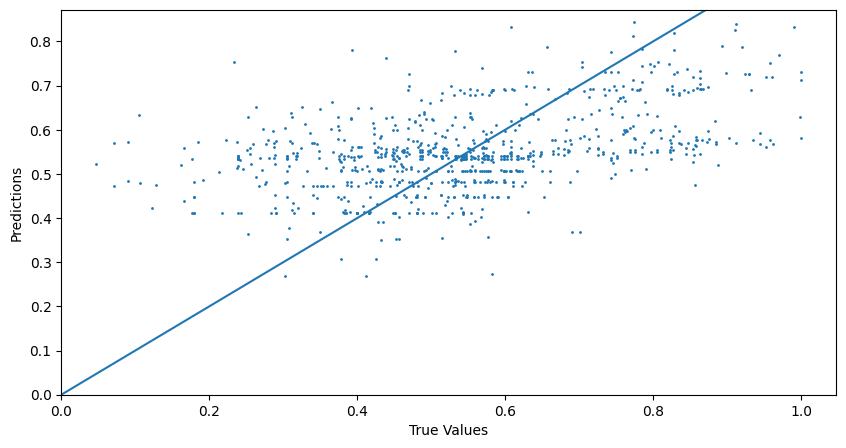

In [39]:
# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(y_test, y_pred, s=1)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100])
plt.show()